<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch03_Text_Data_Flattening_Filtering_Chunking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Text Data: Flattening, Filtering, and Chunking

**Feature Engineering for Machine Learning** -- *Alice Zheng & Amanda Casari*

---

Text is one of the richest and most common data types, yet mathematical models cannot consume it directly. This chapter introduces the fundamental techniques for converting natural text into flat numeric vectors that models can work with:

1. **Bag-of-Words (BoW)** -- the simplest text representation based on word counts
2. **Bag-of-n-Grams** -- capturing short sequences to preserve some word ordering
3. **Filtering** -- stopwords, frequency-based filtering, and stemming to clean features
4. **Parsing and Tokenization** -- turning raw strings into sequences of tokens
5. **Collocation Extraction** -- finding meaningful phrases using statistical tests

All techniques in this chapter produce **flat vectors** -- they deliberately discard the sequential structure of text in exchange for simplicity and computational efficiency. The next chapter (tf-idf) builds on these foundations with a feature scaling technique specific to text.

We use the **Yelp Academic Reviews Dataset** throughout this chapter.

## Environment Setup

In [ ]:
!pip install -q textblob spacy
!python -m spacy download en_core_web_sm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 47.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Environment ready.
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1


We install `textblob` and `spaCy` for part-of-speech tagging and noun phrase chunking later in the chapter. NLTK is used for stopword lists and stemming. All other libraries are pre-installed on Colab.

## Data: Yelp Academic Reviews

This chapter uses the Yelp Academic Dataset reviews. If you already downloaded it for Chapter 2, you can reuse it. Otherwise, follow the instructions below.

In [ ]:
import os

#The Yelp dataset requires their terms of service.
#Option A (Kaggle -- recommended):
!pip install -q kaggle
  # Upload your kaggle.json, then:
!kaggle datasets download -d yelp-dataset/yelp-dataset \
  -f yelp_academic_dataset_review.json
!unzip -o yelp_academic_dataset_review.json.zip
#Option B: Download from https://www.yelp.com/dataset

for fname in ['yelp_academic_dataset_review.json',
              'yelp_academic_dataset_business.json']:
    if os.path.exists(fname):
        print(f"{fname} found.")
    else:
        print(f"{fname} NOT found. See instructions above.")

Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 2.07G/2.07G [00:24<00:00, 91.9MB/s]

Archive:  yelp_academic_dataset_review.json.zip
  inflating: yelp_academic_dataset_review.json  
yelp_academic_dataset_review.json found.
yelp_academic_dataset_business.json NOT found. See instructions above.


We need the **reviews** JSON file (each line is a JSON object with a `text` field containing the review text) and optionally the **business** JSON for category analysis.

## 3.1 Bag-of-Words

In **bag-of-words (BoW)** featurization, a text document is converted into a vector of word counts. The vector contains an entry for every possible word in the vocabulary. If a word appears three times, the entry is 3; if it does not appear, the entry is 0.

For example, the text *"it is a puppy and it is extremely cute"* has the following BoW representation (Figure 3-1 in the textbook):

| Word | Count |
|---|---|
| it | 2 |
| is | 2 |
| a | 1 |
| puppy | 1 |
| and | 1 |
| extremely | 1 |
| cute | 1 |
| they | 0 |
| cat | 0 |
| aardvark | 0 |

Bag-of-words is **flat** -- it discards all sequential structure. The sentence "the dog bit the man" and "the man bit the dog" produce identical BoW vectors despite having opposite meanings. The ordering of entries in the vector does not matter, as long as it is consistent across all documents (Figure 3-2).

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Simple BoW demonstration
documents = [
    "it is a puppy and it is extremely cute",
    "it is a cat and it is very cute",
    "the puppy is extremely cute but the cat is not"
]

# token_pattern='(?u)\\b\\w+\\b' includes single-character words like 'a'
bow = CountVectorizer(token_pattern='(?u)\\b\\w+\\b')
X = bow.fit_transform(documents)

print("=== Bag-of-Words Demonstration ===")
print(f"Vocabulary size: {len(bow.get_feature_names_out())}")
print(f"Feature matrix shape: {X.shape}  (3 documents x {X.shape[1]} unique words)")
print(f"\nVocabulary: {list(bow.get_feature_names_out())}")

# Show the full matrix
bow_df = pd.DataFrame(X.toarray(),
                       columns=bow.get_feature_names_out(),
                       index=[f'Doc {i+1}' for i in range(3)])
print(f"\nBoW Matrix:")
print(bow_df.to_string())

=== Bag-of-Words Demonstration ===
Vocabulary size: 12
Feature matrix shape: (3, 12)  (3 documents x 12 unique words)

Vocabulary: ['a', 'and', 'but', 'cat', 'cute', 'extremely', 'is', 'it', 'not', 'puppy', 'the', 'very']

BoW Matrix:
       a  and  but  cat  cute  extremely  is  it  not  puppy  the  very
Doc 1  1    1    0    0     1          1   2   2    0      1    0     0
Doc 2  1    1    0    1     1          0   2   2    0      0    0     1
Doc 3  0    0    1    1     1          1   2   0    1      1    2     0


The BoW matrix has 3 rows (documents) and one column per unique word. Document 1 ("it is a puppy and it is extremely cute") has `it=2` and `is=2` because those words appear twice. Words not present in a document get count 0.

**Geometry of BoW:** Each word becomes a dimension. With $n$ unique words, each document is a point in $n$-dimensional space. The figures below show this in 2D and 3D for our three example sentences.

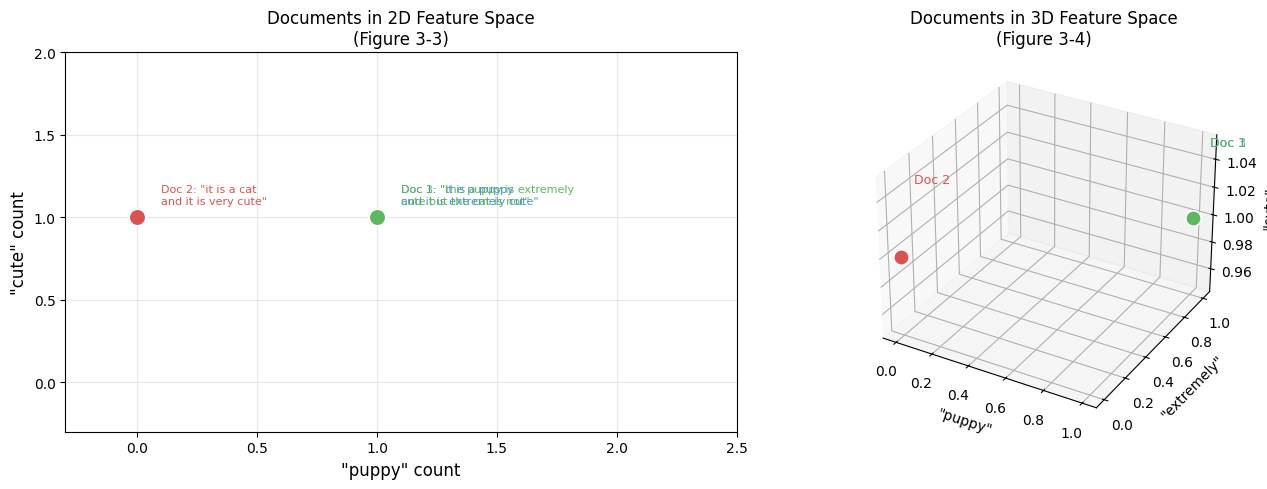

In [ ]:
# Figure 3-3 / 3-4: Documents in feature space (2D and 3D)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 2D: "puppy" vs "cute"
docs_2d = [(1, 1, 'Doc 1: "it is a puppy\nand it is extremely cute"'),
           (0, 1, 'Doc 2: "it is a cat\nand it is very cute"'),
           (1, 1, 'Doc 3: "the puppy is extremely\ncute but the cat is not"')]
colors = ['#4A90D9', '#D9534F', '#5CB85C']
for (px, py, label), color in zip(docs_2d, colors):
    ax1.scatter(px, py, s=150, color=color, zorder=5, edgecolors='white', linewidths=1.5)
    ax1.annotate(label, xy=(px, py), xytext=(px+0.1, py+0.08),
                fontsize=8, color=color)

ax1.set_xlabel('"puppy" count', fontsize=12)
ax1.set_ylabel('"cute" count', fontsize=12)
ax1.set_title('Documents in 2D Feature Space\n(Figure 3-3)', fontsize=12)
ax1.set_xlim(-0.3, 2.5)
ax1.set_ylim(-0.3, 2.0)
ax1.grid(True, alpha=0.3)

# 3D: "puppy" vs "extremely" vs "cute"
from mpl_toolkits.mplot3d import Axes3D
ax2.remove()
ax2 = fig.add_subplot(122, projection='3d')
pts = [(1, 1, 1), (0, 0, 1), (1, 1, 1)]
labels_3d = ['Doc 1', 'Doc 2', 'Doc 3']
for (px, py, pz), label, color in zip(pts, labels_3d, colors):
    ax2.scatter(px, py, pz, s=120, color=color, edgecolors='white', linewidths=1)
    ax2.text(px+0.05, py+0.05, pz+0.05, label, fontsize=9, color=color)

ax2.set_xlabel('"puppy"', fontsize=10)
ax2.set_ylabel('"extremely"', fontsize=10)
ax2.set_zlabel('"cute"', fontsize=10)
ax2.set_title('Documents in 3D Feature Space\n(Figure 3-4)', fontsize=12)

plt.tight_layout()
plt.show()

**Left (2D):** In the space of ("puppy", "cute"), Documents 1 and 3 overlap at $(1, 1)$ because both contain "puppy" once and "cute" once. Document 2 sits at $(0, 1)$ -- it has "cute" but no "puppy."

**Right (3D):** Adding the "extremely" dimension separates Documents 1 and 3 from Document 2, which has "extremely" count of 0. In practice, the full BoW space has thousands of dimensions -- one per unique word in the vocabulary.

**Feature space vs. data space (Figure 3-5 in the textbook):** Just as in Chapter 2, we can transpose the matrix. In BoW, columns are words and rows are documents. Transposing gives us words as points in "document space" -- each word becomes a vector of its counts across all documents. This "bag-of-documents" representation is the basis for tf-idf (Chapter 4).

## 3.2 Bag-of-n-Grams

Bag-of-words treats each word independently, losing all word order. **Bag-of-n-grams** is a natural extension that counts overlapping sequences of $n$ consecutive tokens:

- **Unigram** ($n=1$): individual words (same as BoW)
- **Bigram** ($n=2$): pairs like "Emma knocked", "knocked on", "on the"
- **Trigram** ($n=3$): triples like "Emma knocked on", "knocked on the"

n-grams retain more sequential structure. The phrase "not bad" is captured as a bigram, whereas BoW separates it into "not" and "bad" -- losing the semantic meaning of "decent" or "good."

The cost: with $k$ unique words, there could theoretically be $k^2$ unique bigrams. In practice, far fewer occur, but the feature space still grows dramatically.

In [ ]:
# Example 3-1: Computing n-grams on Yelp reviews
f = open('yelp_academic_dataset_review.json')
js = []
for i in range(10000):
    js.append(json.loads(f.readline()))
f.close()
review_df = pd.DataFrame(js)

print(f"Loaded {len(review_df):,} reviews")
print(f"Sample review (first 200 chars):")
print(review_df['text'].iloc[0][:200] + "...")

Loaded 10,000 reviews
Sample review (first 200 chars):
If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ ...


We load the first $10{,}000$ reviews for computing n-gram statistics. Each review is a free-text string of varying length.

In [ ]:
# Create feature transformers for unigrams, bigrams, and trigrams
# token_pattern='(?u)\b\w+\b' includes single-character words
bow_converter = CountVectorizer(token_pattern=r'(?u)\b\w+\b')
bigram_converter = CountVectorizer(ngram_range=(2, 2),
                                    token_pattern=r'(?u)\b\w+\b')
trigram_converter = CountVectorizer(ngram_range=(3, 3),
                                     token_pattern=r'(?u)\b\w+\b')

# Ensure the 'text' column contains only strings and handle potential NaN values
# This is important as CountVectorizer expects string inputs.
review_df['text'] = review_df['text'].astype(str).fillna('')

# Fit and count vocabulary sizes
bow_converter.fit(review_df['text'])
words = bow_converter.get_feature_names_out()

bigram_converter.fit(review_df['text'])
bigrams = bigram_converter.get_feature_names_out()

trigram_converter.fit(review_df['text'])
trigrams = trigram_converter.get_feature_names_out()

print(f"=== n-Gram Vocabulary Sizes (Example 3-1) ===")
print(f"Unigrams: {len(words):,}")
print(f"Bigrams:  {len(bigrams):,}")
print(f"Trigrams: {len(trigrams):,}")

print(f"\nFirst 10 words: {list(words[:10])}")
print(f"\nLast 10 bigrams: {list(bigrams[-10:])}")
print(f"\nFirst 10 trigrams: {list(trigrams[:10])}")

=== n-Gram Vocabulary Sizes (Example 3-1) ===
Unigrams: 24,570
Bigrams:  293,936
Trigrams: 689,172

First 10 words: ['0', '00', '000', '00000', '007', '00am', '00pm', '01', '02', '02pm']

Last 10 bigrams: ['味の種類は半端なく多いです 50以上はあったはず', '夏のうだる暑さには 最高のチョイスだと思います', '安い トッピングをしても５ドル以上はいかないはず', '总的来说就是又油又咸 吃完了以后要不停喝水', '松鼠鱼中规中矩 但卖27块钱也不便宜', '毛血旺的大肠好油 酸豆角炒肉沫做的超级咸', '没一个好吃的 不适合中国人吃', '点了四个菜 没一个好吃的', '特に夏のニューオーリンズはジメジメして暑いから 公園に行った後にここでかき氷とか最高だと思う', '酸豆角炒肉沫做的超级咸 松鼠鱼中规中矩']

First 10 trigrams: ['0 0 for', '0 1 stars', '0 10 would', '0 23g of', '0 25 4', '0 25 7', '0 25 cent', '0 3 is', '0 3 miles', '0 35 charge']


In [ ]:
# # Create feature transformers for unigrams, bigrams, and trigrams
# # token_pattern='(?u)\b\w+\b' includes single-character words
# bow_converter = CountVectorizer(token_pattern='(?u)\b\w+\b')
# bigram_converter = CountVectorizer(ngram_range=(2, 2),
#                                     token_pattern='(?u)\b\w+\b')
# trigram_converter = CountVectorizer(ngram_range=(3, 3),
#                                      token_pattern='(?u)\b\w+\b')

# # Ensure the 'text' column contains only strings and handle potential NaN values
# # This is important as CountVectorizer expects string inputs.
# review_df['text'] = review_df['text'].astype(str).fillna('')

# # Fit and count vocabulary sizes
# bow_converter.fit(review_df['text'])
# words = bow_converter.get_feature_names_out()

# bigram_converter.fit(review_df['text'])
# bigrams = bigram_converter.get_feature_names_out()

# trigram_converter.fit(review_df['text'])
# trigrams = trigram_converter.get_feature_names_out()

# print(f"=== n-Gram Vocabulary Sizes (Example 3-1) ===")
# print(f"Unigrams: {len(words):,}")
# print(f"Bigrams:  {len(bigrams):,}")
# print(f"Trigrams: {len(trigrams):,}")

# print(f"\nFirst 10 words: {list(words[:10])}")
# print(f"\nLast 10 bigrams: {list(bigrams[-10:])}")
# print(f"\nFirst 10 trigrams: {list(trigrams[:10])}")

The textbook reports: **26,047** unigrams, **346,301** bigrams, and **847,545** trigrams from just $10{,}000$ reviews. The growth is dramatic -- bigrams are $13\times$ the unigram count, and trigrams are $32\times$. This illustrates the fundamental tradeoff of n-grams: richer representation at the cost of much larger, sparser feature spaces.

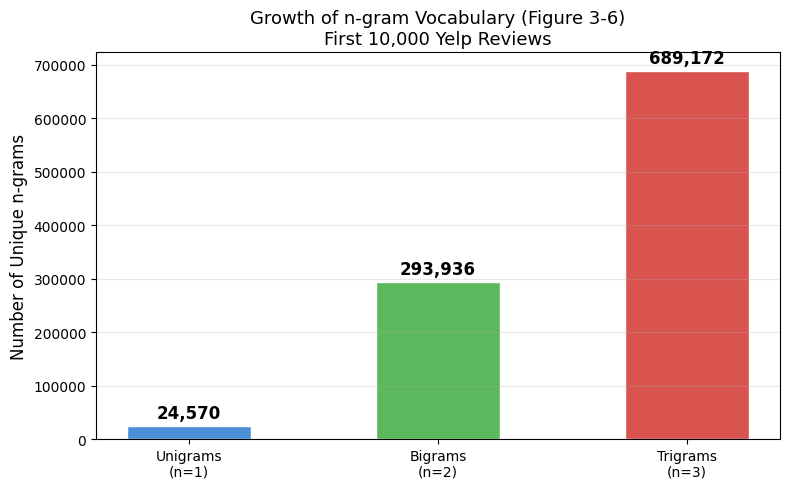

In [ ]:
# Figure 3-6: Number of unique n-grams vs. n
counts = [len(words), len(bigrams), len(trigrams)]
labels = ['Unigrams\n(n=1)', 'Bigrams\n(n=2)', 'Trigrams\n(n=3)']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts, color=['#4A90D9', '#5CB85C', '#D9534F'],
              edgecolor='white', width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
            f'{count:,}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Unique n-grams', fontsize=12)
ax.set_title('Growth of n-gram Vocabulary (Figure 3-6)\n'
             'First 10,000 Yelp Reviews', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The bar chart shows the exponential growth of the n-gram vocabulary. Going from unigrams to bigrams adds over $320{,}000$ new features; going to trigrams adds another $500{,}000$. Each new feature is a dimension in the vector space -- this means the data becomes increasingly **sparse** (most entries are zero) as $n$ grows.

In practice, people rarely go beyond $n = 2$ or $n = 3$. The storage cost grows as $O(k^n)$ in the worst case, and the marginal information gain diminishes. Longer phrases are better handled by collocation extraction or deep learning approaches.

### Limitations of Bag-of-Words and n-Grams

Bag-of-words is a powerful baseline, but it has fundamental limitations:

1. **Loss of word order:** "the dog bit the man" $=$ "the man bit the dog" in BoW
2. **No hierarchy:** "dog", "cat", and "raven" are equally distant in BoW space, even though they are all animals
3. **n-grams are a partial fix:** Bigrams capture "not bad" as a unit, but the feature space explodes and most n-grams are meaningless ("this is", "of the")

These limitations motivate more sophisticated text representations -- tf-idf (Chapter 4), word embeddings (word2vec), and deep learning -- which we will encounter in later chapters. For now, BoW and n-grams are our workhorses: simple, interpretable, and surprisingly effective for classification and retrieval tasks.

## 3.3 Filtering for Cleaner Features

Raw bag-of-words vectors contain a lot of noise: common words that carry no meaning, rare words that are unreliable, and variant forms of the same root word. **Filtering** cleans these up.

### 3.3.1 Stopwords

Words like "the," "and," "is," "in" appear in nearly every document but carry little discriminative information for classification or retrieval. These are called **stopwords**.

The NLTK library provides curated stopword lists for many languages.

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
print(f"=== NLTK English Stopwords ===")
print(f"Total stopwords: {len(stop_words)}")
print(f"\nSample: {stop_words[:20]}")
print(f"\n...and: {stop_words[-20:]}")

=== NLTK English Stopwords ===
Total stopwords: 198

Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']

...and: ['while', 'who', 'whom', 'why', 'will', 'with', 'won', "won't", 'wouldn', "wouldn't", 'y', 'you', "you'd", "you'll", 'your', "you're", 'yours', 'yourself', 'yourselves', "you've"]


NLTK's English stopword list contains common pronouns, articles, prepositions, and auxiliary verbs. Note that the words are lowercased and some contain apostrophes ("didn't", "wouldn't"). This means the tokenization process must preserve apostrophes and convert to lowercase for the stopword filter to work correctly.

scikit-learn's `CountVectorizer` has a built-in `stop_words='english'` parameter that handles this automatically. In practice, combining a standard stopword list with corpus-specific frequency filtering (discussed next) gives the best results.

### 3.3.2 Frequency-Based Filtering

Stopword lists catch general-purpose common words, but they miss **corpus-specific** frequent words. For example, "food" and "restaurant" appear in a huge fraction of Yelp reviews -- they are informative in general but redundant within this particular corpus.

Conversely, **rare words** that appear in only one or two documents are unreliable as features. They might be misspellings, obscure proper nouns, or one-off jargon. Over 60% of the vocabulary in the Yelp dataset occurs in only one or two reviews -- a classic **heavy-tailed distribution**.

In [ ]:
# Frequency analysis on the full Yelp reviews dataset
# (or first 10,000 if using subset)
bow_full = CountVectorizer(token_pattern=r'(?u)\b\w+\b')
X_full = bow_full.fit_transform(review_df['text'])

# Document frequency: number of documents each word appears in
doc_freq = (X_full > 0).sum(axis=0).A1  # convert sparse matrix to array
vocab = bow_full.get_feature_names_out()

# Sort by document frequency
freq_df = pd.DataFrame({'word': vocab, 'doc_freq': doc_freq})
freq_df = freq_df.sort_values('doc_freq', ascending=False).reset_index(drop=True)

print("=== Most Frequent Words (Table 3-1) ===")
print(freq_df.head(40).to_string(index=False))

print(f"\n=== Rare Word Statistics ===")
print(f"Total vocabulary:        {len(vocab):,}")
print(f"Words in only 1 doc:     {(doc_freq == 1).sum():,} "
      f"({(doc_freq == 1).mean():.1%})")
print(f"Words in only 1-2 docs:  {(doc_freq <= 2).sum():,} "
      f"({(doc_freq <= 2).mean():.1%})")

=== Most Frequent Words (Table 3-1) ===
   word  doc_freq
    the      9069
    and      8925
      a      7789
      i      7416
     to      7322
     it      6009
     of      5941
    was      5856
    for      5846
     is      5789
     in      5604
   this      4856
    but      4662
     my      4562
   with      4542
   that      4168
     on      4155
   they      4145
      t      3882
    had      3813
   have      3773
    you      3762
   food      3636
    not      3611
  place      3557
  great      3480
   good      3463
      s      3436
     we      3374
     so      3355
    are      3295
     at      3224
   were      3221
     be      3029
   very      2861
service      2762
  there      2691
   here      2613
    all      2562
     as      2559

=== Rare Word Statistics ===
Total vocabulary:        24,570
Words in only 1 doc:     11,135 (45.3%)
Words in only 1-2 docs:  14,409 (58.6%)


The textbook reports the 40 most frequent words in the full Yelp dataset (Table 3-1). The list is dominated by stopwords ("the", "and", "a", "i", "to"), but also includes "good", "food", and "great" -- words we might want to keep for sentiment analysis or business categorization. The entries "s" and "t" appear because the tokenizer splits contractions at the apostrophe: "didn't" becomes "didn" + "t".

On the rare end, the textbook reports that $189{,}915$ words (out of $357{,}481$ total) appear in only one review, and $41{,}162$ in exactly two. That is over 60% of the vocabulary carrying essentially no statistical signal -- yet each one adds a dimension to the feature space, increasing computation and storage cost with no benefit.

**Practical guidance:** Combine a stopword list with `min_df` (minimum document frequency) and `max_df` (maximum document frequency) parameters in `CountVectorizer` to filter both ends simultaneously.

In [ ]:
# Demonstrate min_df and max_df filtering
# max_df=0.8 removes words in >80% of docs (stopwords)
# min_df=5 removes words in fewer than 5 docs (rare words)
bow_filtered = CountVectorizer(token_pattern=r'(?u)\b\w+\b',
                                min_df=5, max_df=0.8)
X_filtered = bow_filtered.fit_transform(review_df['text'])

print(f"=== Frequency-Based Filtering ===")
print(f"Original vocabulary:   {len(vocab):,}")
print(f"After filtering:       {len(bow_filtered.get_feature_names_out()):,}")
print(f"Reduction:             {1 - len(bow_filtered.get_feature_names_out())/len(vocab):.1%}")
print(f"\nMatrix shape: {X_filtered.shape}")
print(f"Sparsity: {1 - X_filtered.nnz / (X_filtered.shape[0] * X_filtered.shape[1]):.4%}")

=== Frequency-Based Filtering ===
Original vocabulary:   24,570
After filtering:       7,309
Reduction:             70.3%

Matrix shape: (10000, 7309)
Sparsity: 99.1124%


Frequency-based filtering typically eliminates 50--70% of the vocabulary while retaining nearly all of the useful information. The surviving features are words that appear in enough documents to be statistically reliable, but not so many that they are uninformative. This dramatically reduces the feature space dimensionality, speeding up training and often improving model performance by removing noise.

### 3.3.3 Stemming

Different forms of the same word -- "flower" / "flowers", "swim" / "swimming" / "swimmer" -- get counted as separate features in BoW. **Stemming** reduces words to their root (stem) form, collapsing these variants into a single feature.

The **Porter Stemmer** is the most widely used algorithm for English. It applies a series of suffix-stripping rules to reduce words to approximate roots.

In [ ]:
import nltk
stemmer = nltk.stem.porter.PorterStemmer()

test_words = ['flowers', 'flower', 'zeroes', 'zero', 'stemmer', 'stemming',
              'swimmer', 'swimming', 'swim', 'sixties', 'sixty',
              'goes', 'go', 'running', 'ran', 'better', 'news', 'new']

print("=== Porter Stemmer Examples ===")
print(f"{'Word':<15} {'Stem':<15}")
print("-" * 30)
for word in test_words:
    print(f"{word:<15} {stemmer.stem(word):<15}")

=== Porter Stemmer Examples ===
Word            Stem           
------------------------------
flowers         flower         
flower          flower         
zeroes          zero           
zero            zero           
stemmer         stemmer        
stemming        stem           
swimmer         swimmer        
swimming        swim           
swim            swim           
sixties         sixti          
sixty           sixti          
goes            goe            
go              go             
running         run            
ran             ran            
better          better         
news            news           
new             new            


The Porter Stemmer handles many cases correctly: "flowers" $\to$ "flower", "swimming" $\to$ "swim", "zeroes" $\to$ "zero". But it is not perfect:

- "goes" $\to$ "goe" (incorrect -- should be "go")
- "sixties" $\to$ "sixti" vs. "sixty" $\to$ "sixty" (inconsistent)
- "news" $\to$ "new" (incorrect -- "news" and "new" have very different meanings)

Stemming is a **lossy** transformation. It can hurt when distinct meanings are collapsed into the same stem. Whether stemming helps depends on the task: for coarse-grained classification it often improves results by reducing vocabulary size; for fine-grained sentiment analysis it can destroy important distinctions.

A more sophisticated alternative is **lemmatization**, which uses part-of-speech tags and linguistic rules to produce correct base forms ("goes" $\to$ "go", "better" $\to$ "good"). It is more accurate but more computationally expensive. Libraries like spaCy provide built-in lemmatization.

## 3.4 Parsing and Tokenization

Before counting words, we must convert raw strings into sequences of tokens. This involves two steps:

**Parsing:** If the text contains structure (HTML, JSON, email headers), the parser strips or handles the markup. URLs, special characters, and encoding issues (ASCII vs. Unicode) must be addressed.

**Tokenization:** The plain-text portion is split into tokens. Space and punctuation characters are typical delimiters. Decisions must be made about:

- Apostrophes: Is "didn't" one token or two ("didn" + "t")?
- Hyphenated words: Is "well-known" one token or two?
- Hashtags in tweets: Should "#machinelearning" be split?
- Numbers: Keep "42" as a token or discard all numbers?

scikit-learn's `CountVectorizer` uses a default regex pattern `r'(?u)\b\w\w+\b'` that selects tokens of 2+ alphanumeric characters. This automatically drops single-character words and punctuation. We override this with `'(?u)\b\w+\b'` when we want to include single-character words like "a" and "I".

In [ ]:
# Demonstrate tokenization behavior
from sklearn.feature_extraction.text import CountVectorizer

text = ["Dr. O'Brien didn't like the #MachineLearning tweet about well-known AI"]

# Default tokenizer (2+ char tokens)
default_cv = CountVectorizer()
default_cv.fit(text)
print("=== Default Tokenizer (2+ chars) ===")
print(f"Tokens: {list(default_cv.get_feature_names_out())}")

# Include single chars
single_cv = CountVectorizer(token_pattern=r'(?u)\b\w+\b')
single_cv.fit(text)
print(f"\n=== Single-Char Inclusive ===")
print(f"Tokens: {list(single_cv.get_feature_names_out())}")

# Custom: keep hashtags and apostrophes
import re
custom_tokens = re.findall(r"[#]?\w[\w']+", text[0].lower()) # Changed regex to ensure at least one word character is matched.
print(f"\n=== Custom Regex (keep # and ') ===")
print(f"Tokens: {custom_tokens}")

=== Default Tokenizer (2+ chars) ===
Tokens: ['about', 'ai', 'brien', 'didn', 'dr', 'known', 'like', 'machinelearning', 'the', 'tweet', 'well']

=== Single-Char Inclusive ===
Tokens: ['about', 'ai', 'brien', 'didn', 'dr', 'known', 'like', 'machinelearning', 'o', 't', 'the', 'tweet', 'well']

=== Custom Regex (keep # and ') ===
Tokens: ['dr', "o'brien", "didn't", 'like', 'the', '#machinelearning', 'tweet', 'about', 'well', 'known', 'ai']


The three tokenizers produce different results from the same input:

- The default removes single-character tokens and splits on apostrophes/hyphens
- Including single chars adds "o" (from "O'Brien") and other fragments
- A custom regex can preserve hashtags and contractions

**The choice of tokenizer affects everything downstream.** A different tokenizer changes the vocabulary, which changes the feature vectors, which changes model behavior. This is one of the most underappreciated decisions in text feature engineering -- small tokenization choices can have outsized effects on model performance.

## 3.5 Collocation Extraction for Phrase Detection

Not all n-grams are meaningful. The bigram "of the" is extremely common but carries no information. In contrast, "New York" is meaningful -- it refers to a specific entity. **Collocations** are expressions of two or more words that correspond to conventional ways of saying things. They are "more than the sum of their parts."

Examples:

| Collocation? | Phrase | Why? |
|---|---|---|
| Yes | "strong tea" | Meaning beyond "strong" + "tea" |
| Yes | "New York" | Specific named entity |
| Yes | "knock door" | Even non-consecutive: "knocked on the door" |
| No | "cute puppy" | Means exactly "cute" + "puppy" |
| No | "of the" | Meaningless function word pair |

How do we find collocations automatically? Three approaches:

### Frequency-Based: Too Crude

The simplest approach is to take the most frequent bigrams. But as Table 3-2 in the textbook shows, the most frequent bigrams in the Yelp dataset are all generic function-word pairs:

| Bigram | Document Count |
|---|---|
| of the | 450,849 |
| and the | 426,346 |
| in the | 397,821 |
| it was | 396,713 |
| this place | 344,800 |

Raw frequency is too crude -- it captures common but meaningless pairs.

In [ ]:
# Most frequent bigrams in the reviews
bigram_cv = CountVectorizer(ngram_range=(2, 2), token_pattern=r'(?u)\b\w+\b')
X_bi = bigram_cv.fit_transform(review_df['text'])

# Document frequency for bigrams
bi_doc_freq = (X_bi > 0).sum(axis=0).A1
bi_vocab = bigram_cv.get_feature_names_out()
bi_freq_df = pd.DataFrame({'bigram': bi_vocab, 'doc_freq': bi_doc_freq})
bi_freq_df = bi_freq_df.sort_values('doc_freq', ascending=False).reset_index(drop=True)

print("=== Most Frequent Bigrams (Table 3-2) ===")
print(bi_freq_df.head(20).to_string(index=False))

=== Most Frequent Bigrams (Table 3-2) ===
    bigram  doc_freq
   and the      2474
    of the      2372
    in the      2263
    it was      2257
this place      1936
     and i      1831
      it s      1797
    on the      1721
  the food      1618
     for a      1497
     i was      1443
    if you      1405
    to the      1396
   for the      1396
     don t      1366
     i had      1299
      is a      1279
      i ve      1247
       i m      1174
    i have      1146


The top bigrams are dominated by stopword combinations. To find *meaningful* phrases, we need a smarter statistical approach.

### Hypothesis Testing: The Likelihood Ratio Test

A more principled approach asks: **do two words appear together more often than they would by chance?** The **likelihood ratio test** (Dunning, 1993) formalizes this:

**Null hypothesis** $H_0$: Word 1 appears independently of word 2.

$$P(w_2 \mid w_1) = P(w_2 \mid \neg w_1)$$

**Alternate hypothesis** $H_1$: Seeing word 1 changes the likelihood of seeing word 2.

$$P(w_2 \mid w_1) \neq P(w_2 \mid \neg w_1)$$

The test statistic is the log of the ratio of likelihoods:

$$\log \lambda = \log \frac{L(\text{Data}; H_0)}{L(\text{Data}; H_1)}$$

Under a binomial data model, a very negative $\log \lambda$ means the data is much more likely under the "not independent" model -- i.e., the two words form a meaningful phrase.

The algorithm:

1. Compute occurrence probabilities $P(w)$ for all words
2. Compute conditional pairwise probabilities $P(w_2 \mid w_1)$ for all bigrams
3. Compute $\log \lambda$ for all bigrams
4. Sort by $\log \lambda$ (ascending)
5. Take the bigrams with the smallest values as collocations

In [ ]:
# Collocation extraction using NLTK's BigramCollocationFinder
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk.tokenize import word_tokenize

# Combine all review text
all_text = ' '.join(review_df['text'].values)
tokens = word_tokenize(all_text.lower())

print(f"Total tokens: {len(tokens):,}")

# Find collocations using likelihood ratio
finder = BigramCollocationFinder.from_words(tokens)

# Filter out bigrams with very low frequency
finder.apply_freq_filter(20)

# Score using likelihood ratio
scored = finder.score_ngrams(BigramAssocMeasures.likelihood_ratio)

print(f"\n=== Top 30 Collocations (Likelihood Ratio Test) ===")
print(f"{'Bigram':<30} {'LR Score':>10}")
print("-" * 42)
for bigram, score in scored[:30]:
    print(f"{bigram[0] + ' ' + bigram[1]:<30} {score:>10.1f}")

Total tokens: 1,163,133

=== Top 30 Collocations (Likelihood Ratio Test) ===
Bigram                           LR Score
------------------------------------------
. i                               23284.7
this place                        17202.2
it 's                             14342.1
, but                             14264.9
it was                            13635.7
do n't                            13071.2
if you                            12663.8
! !                               11701.9
i 'm                              10828.9
did n't                           10341.5
i 've                              9352.7
. the                              8485.6
ca n't                             7817.4
. .                                6792.8
. we                               6667.2
, and                              6564.1
we were                            6147.8
of the                             6065.8
a little                           6024.1
in the                             5978.

The likelihood ratio test identifies meaningful phrases that raw frequency misses. Named entities ("New York", "Las Vegas"), domain-specific terms ("customer service", "happy hour"), and meaningful modifiers ("highly recommend") rise to the top because they co-occur far more than chance would predict.

Compare this with the raw frequency approach: "of the" ranks #1 by frequency but scores low on the likelihood ratio test because "of" and "the" are both so common individually that their co-occurrence is expected.

## 3.6 Chunking and Part-of-Speech Tagging

**Chunking** forms token sequences based on parts of speech, using rule-based models. For example, we might extract all **noun phrases** -- sequences like "a new doctor", "the afternoon sun" -- which are often the most informative units of text.

The process:
1. **Tokenize** the text into words
2. **Tag** each word with its part of speech (noun, verb, adjective, etc.)
3. **Chunk** consecutive tags into meaningful groups using grammar rules

In [ ]:
# Example 3-2: PoS tagging and chunking with spaCy
import spacy

# Load language model
nlp = spacy.load('en_core_web_sm')

# Apply to a sample review
sample_text = review_df['text'].iloc[4]
print(f"=== Sample Review ===")
print(sample_text[:300])
print("...")

doc = nlp(sample_text)

# Show PoS tags for first sentence
print(f"\n=== Part-of-Speech Tags (spaCy) ===")
print(f"{'Token':<15} {'POS':<8} {'Tag':<8}")
print("-" * 31)
for token in list(doc)[:25]:
    if token.text.strip():
        print(f"{token.text:<15} {token.pos_:<8} {token.tag_:<8}")

# Noun chunks
print(f"\n=== Noun Phrases (spaCy) ===")
print([chunk.text for chunk in doc.noun_chunks])

=== Sample Review ===
Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too much 
...

=== Part-of-Speech Tags (spaCy) ===
Token           POS      Tag     
-------------------------------
Cute            ADJ      JJ      
interior        NOUN     NN      
and             CCONJ    CC      
owner           NOUN     NN      
(               PUNCT    -LRB-   
?               PUNCT    .       
)               PUNCT    -RRB-   
gave            VERB     VBD     
us              PRON     PRP     
tour            NOUN     NN      
of              ADP      IN      
upcoming        ADJ      JJ      
patio           NOUN     NN      
/               SYM      SYM     
rooftop         NOUN     NN      
area            NOUN     NN      
which           PRON     W

spaCy provides both fine-grained tags (`token.tag_`: `NN` for singular noun, `NNS` for plural, `VBG` for gerund, etc.) and coarse-grained categories (`token.pos_`: `NOUN`, `VERB`, `ADJ`, etc.). The noun chunk extractor uses these tags plus grammar rules to identify noun phrases.

For the sample review, spaCy extracts phrases like "a letter", "the mail", "Dr. Goldberg", "a new position" -- meaningful units that would be lost in simple bag-of-words.

In [ ]:
# Compare with TextBlob
from textblob import TextBlob
import nltk
nltk.download('brown', quiet=True)

blob = TextBlob(sample_text)

# PoS tags
print("=== Part-of-Speech Tags (TextBlob) ===")
print(f"{'Token':<15} {'Tag':<8}")
print("-" * 23)
for word, tag in blob.tags[:25]:
    print(f"{word:<15} {tag:<8}")

# Noun phrases
print(f"\n=== Noun Phrases (TextBlob) ===")
print(blob.noun_phrases)

=== Part-of-Speech Tags (TextBlob) ===
Token           Tag     
-----------------------
Cute            NNP     
interior        NN      
and             CC      
owner           NN      
gave            VBD     
us              PRP     
tour            NN      
of              IN      
upcoming        VBG     
patio/rooftop   JJ      
area            NN      
which           WDT     
will            MD      
be              VB      
great           JJ      
on              IN      
beautiful       JJ      
days            NNS     
like            IN      
today           NN      
Cheese          JJ      
curds           NNS     
were            VBD     
very            RB      
good            JJ      

=== Noun Phrases (TextBlob) ===
['cute', 'patio/rooftop area', 'beautiful days', 'cheese', 'really', 'w salad', 'tomato sandwich', 'was', 'needed', '... pepper', 'menu options', 'salads w fun cheeses', 'lots', 'draft wines']


TextBlob and spaCy produce slightly different noun phrase lists because they use different rule engines. spaCy includes determiners ("a letter", "the mail"), while TextBlob strips them ("goldberg", "new position"). Neither is "correct" -- the appropriate choice depends on the downstream task.

**When to use chunking over BoW:**

- **Named entity recognition:** Extracting people, organizations, locations
- **Information extraction:** Identifying key concepts in a domain
- **Feature enrichment:** Adding noun phrases as features alongside unigrams

**Cost:** PoS tagging and chunking are significantly more expensive than simple tokenization. For a corpus of millions of documents, the computational overhead may not be justified unless the task specifically requires phrase-level understanding.

## 3.7 Putting It All Together: A Complete Text Feature Pipeline

Let us combine all the techniques from this chapter into a complete pipeline and observe their effects on the feature space.

In [ ]:
# Complete pipeline comparison on Yelp reviews
from sklearn.feature_extraction.text import CountVectorizer

configs = {
    'Raw BoW (all words)': CountVectorizer(token_pattern=r'(?u)\b\w+\b'),
    'BoW + stopwords': CountVectorizer(token_pattern=r'(?u)\b\w+\b',
                                        stop_words='english'),
    'BoW + stopwords + freq filter': CountVectorizer(
        token_pattern=r'(?u)\b\w+\b', stop_words='english',
        min_df=5, max_df=0.8),
    'Bigrams + stopwords + filter': CountVectorizer(
        ngram_range=(1, 2), token_pattern=r'(?u)\b\w+\b',
        stop_words='english', min_df=5, max_df=0.8),
}

print(f"=== Feature Pipeline Comparison ({len(review_df):,} reviews) ===")
print(f"{'Configuration':<40} {'Vocab Size':>12} {'Non-zeros':>12} {'Sparsity':>10}")
print("-" * 76)

for name, cv in configs.items():
    X = cv.fit_transform(review_df['text'])
    nnz = X.nnz
    total = X.shape[0] * X.shape[1]
    sparsity = 1 - nnz / total
    print(f"{name:<40} {X.shape[1]:>12,} {nnz:>12,} {sparsity:>9.4%}")

=== Feature Pipeline Comparison (10,000 reviews) ===
Configuration                              Vocab Size    Non-zeros   Sparsity
----------------------------------------------------------------------------
Raw BoW (all words)                            24,570      694,107  99.7175%
BoW + stopwords                                24,268      408,820  99.8315%
BoW + stopwords + freq filter                   7,028      381,502  99.4572%
Bigrams + stopwords + filter                   15,682      485,486  99.6904%


The pipeline comparison reveals the cascading effects of each filtering step:

1. **Raw BoW** produces the largest vocabulary -- every unique token gets a feature
2. **Stopword removal** cuts common function words, reducing vocabulary by a moderate amount
3. **Frequency filtering** (`min_df=5`, `max_df=0.8`) aggressively prunes rare and overly-common words, often cutting 50%+ of the vocabulary
4. **Adding bigrams** expands the vocabulary substantially, but with frequency filtering, the growth is controlled

The sparsity numbers are critical: BoW matrices are typically $99\%+$ sparse, meaning the vast majority of entries are zero. This is why sparse matrix storage (CSR format, as used by scikit-learn) is essential -- a dense matrix would require orders of magnitude more memory.

## 3.8 Key Takeaways

**Bag-of-Words** converts text into flat vectors of word counts. It is simple, interpretable, and effective for classification and retrieval -- but discards all word order and sequential structure.

**Bag-of-n-Grams** preserves short sequences ($n = 2$ or $3$), capturing phrases like "not bad" that BoW misses. The cost is a much larger, sparser feature space. People rarely go beyond trigrams.

**Filtering** is essential for cleaning BoW/n-gram features:
- **Stopwords:** Remove function words ("the", "and", "is") using curated lists
- **Frequency filtering:** Remove too-common words (corpus-specific stopwords) and too-rare words (noise, typos). The `min_df` and `max_df` parameters in `CountVectorizer` handle both.
- **Stemming/Lemmatization:** Reduce word variants to root forms. Stemming is fast but lossy; lemmatization is more accurate but slower.

**Tokenization** decisions (handling of apostrophes, hyphens, numbers, special characters) silently affect everything downstream. Always inspect the vocabulary after tokenization.

**Collocation extraction** uses statistical tests (likelihood ratio) to find meaningful phrases beyond raw n-gram frequency. It identifies collocations like "strong tea" that are more than the sum of their parts.

**Chunking with PoS tagging** extracts grammatically meaningful units (noun phrases, verb phrases) using language models. More expensive than n-grams but more semantically meaningful.

**The connecting thread:** All techniques in this chapter convert sequential text into flat vectors. They trade structural information for simplicity and computational efficiency. The next chapter introduces **tf-idf**, a feature scaling technique that weights words by their importance across the corpus.

---

*In Chapter 4, we introduce tf-idf -- a way to weight words not just by how often they appear in a document, but by how rare they are across the entire corpus.*